محمد عبد الرزاق كركوتلي


نعمات بلال اسعد


احمد الحاتي


رابط  ملف أوزان المودل


https://drive.usercontent.google.com/download?id=1hpfXnJ3aSklcMe6wai_YVGfK_Otb24f5&authuser=0

🔄 جاري تهيئة الموديل...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ تم تحميل الأوزان بنجاح: smart_arabert_v2_balanced.pt
🧐 جاري معالجة 9 سطر وتحليل الأداء...


Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]


🔍 تحليل الأخطاء (تم العثور على 5 خطأ من أصل 86 كلمة):

📊 تقرير التصنيف النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       1.00      0.97      0.99        73
       فاصلة       0.75      1.00      0.86         3
        نقطة       0.50      1.00      0.67         2
     استفهام       0.50      1.00      0.67         2
      نقطتان       1.00      1.00      1.00         1
      منقوطة       0.00      0.00      0.00         0
        تعجب       1.00      0.40      0.57         5

    accuracy                           0.94        86
   macro avg       0.68      0.77      0.68        86
weighted avg       0.97      0.94      0.94        86



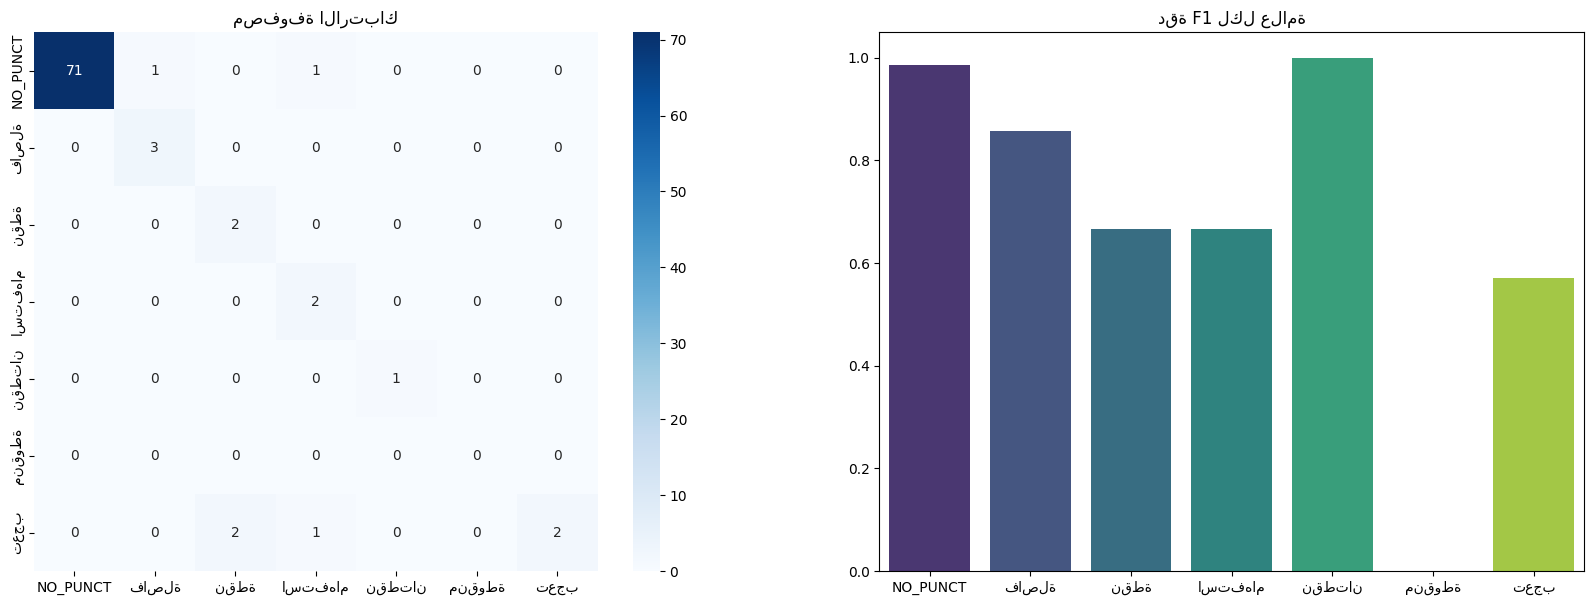

السطر,الكلمة,الحقيقية,التوقع,الحالة
3,عظيما,!,؟,❌
5,شيء,!,.,❌
6,بوسعك,🚫,؟,❌
8,رائع,🚫,،,❌
8,صديقي,!,.,❌


In [ ]:
import os
import torch
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML

# =================== 1. الإعدادات والتحميل العام ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "aubmindlab/bert-base-arabertv02"

# --- تحميل الأوزان من الرابط العام ---
file_id = '1hpfXnJ3aSklcMe6wai_YVGfK_Otb24f5'
model_url = f'https://drive.google.com/uc?id={file_id}'
MODEL_WEIGHTS = 'smart_arabert_v2_balanced.pt'

if not os.path.exists(MODEL_WEIGHTS):
    print("📥 جاري تحميل أوزان الموديل من الرابط العام (Drive)...")
    gdown.download(model_url, MODEL_WEIGHTS, quiet=False)

# مسار ملف الاختبار (يمكنك تعديله لأي ملف آخر)
TEST_FILE_PATH = '/content/any.txt'

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
LABELS_CHARS = ["", "،", ".", "؟", ":", "؛", "!"]
NUM_LABELS = len(PUNCTUATION_LABELS)
MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}
INV_MAPPING = {v: (k if k != "" else "🚫") for k, v in MAPPING_REV.items()}

# =================== 2. وظائف المعالجة والتوقع ===================

def predict_long_text_v2(text, model, tokenizer, device, max_len=128):
    model.eval()
    clean_text = re.sub(r'[،.,؟?:;!]', '', text)
    words = clean_text.split()
    chunk_size = 100
    all_words_with_punct = []
    mapping = {i: char for i, char in enumerate(LABELS_CHARS)}

    for i in range(0, len(words), chunk_size):
        chunk_words = words[i : i + chunk_size]
        inputs = tokenizer(chunk_words, is_split_into_words=True, truncation=True,
                           max_length=max_len, padding='max_length', return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

        word_ids = inputs.word_ids()
        prev_w_idx = None
        for idx, w_idx in enumerate(word_ids):
            if w_idx is not None and w_idx != prev_w_idx:
                if w_idx < len(chunk_words):
                    word = chunk_words[w_idx]
                    label_id = predictions[idx]
                    symbol = mapping.get(label_id, "")
                    all_words_with_punct.append(word + symbol)
                prev_w_idx = w_idx
    return " ".join(all_words_with_punct)

def evaluate_best_model(test_file_path, model, tokenizer, device):
    all_true_labels, all_pred_labels, comparison_data = [], [], []

    if not os.path.exists(test_file_path):
        print(f"❌ خطأ: الملف غير موجود في {test_file_path}"); return None

    with open(test_file_path, 'r', encoding='utf-8') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    print(f"🧐 جاري معالجة {len(lines)} سطر وتحليل الأداء...")

    for line_idx, raw_text in enumerate(tqdm(lines, desc="Evaluating")):
        text_fixed = raw_text.replace(',', '،')
        text_fixed = re.sub(r'\s+([،.؟:؛!])', r'\1', text_fixed)
        tokens = text_fixed.split()
        clean_words, true_labels = [], []
        for t in tokens:
            match = re.search(r'([،.؟:؛!])$', t)
            if match:
                symbol, word = match.group(1), t[:-1]
                label = MAPPING_REV.get(symbol, 0)
            else:
                word, label = t, 0
            if word:
                clean_words.append(word); true_labels.append(label)

        input_text = " ".join(clean_words)
        predicted_text = predict_long_text_v2(input_text, model, tokenizer, device)
        pred_tokens = predicted_text.split()

        for j in range(min(len(clean_words), len(pred_tokens))):
            word, t_lab = clean_words[j], true_labels[j]
            m_p = re.search(r'([،.؟:؛!])$', pred_tokens[j])
            p_lab = MAPPING_REV.get(m_p.group(1), 0) if m_p else 0
            all_true_labels.append(t_lab)
            all_pred_labels.append(p_lab)
            comparison_data.append({
                "السطر": line_idx + 1, "الكلمة": word,
                "الحقيقية": INV_MAPPING[t_lab], "التوقع": INV_MAPPING[p_lab],
                "الحالة": "✅" if t_lab == p_lab else "❌"
            })

    full_df = pd.DataFrame(comparison_data)
    errors_df = full_df[full_df["الحالة"] == "❌"]

    print("\n" + "="*50)
    print(f"🔍 تحليل الأخطاء (تم العثور على {len(errors_df)} خطأ من أصل {len(full_df)} كلمة):")
    print("="*50)

    print("\n📊 تقرير التصنيف النهائي:")
    print(classification_report(all_true_labels, all_pred_labels, labels=range(NUM_LABELS), target_names=PUNCTUATION_LABELS, zero_division=0))


    fig, ax = plt.subplots(1, 2, figsize=(20, 7))
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=range(NUM_LABELS))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=PUNCTUATION_LABELS, yticklabels=PUNCTUATION_LABELS, ax=ax[0])
    ax[0].set_title('مصفوفة الارتباك')

    report_dict = classification_report(all_true_labels, all_pred_labels, labels=range(NUM_LABELS), target_names=PUNCTUATION_LABELS, output_dict=True, zero_division=0)
    f1_vals = [report_dict[label]['f1-score'] for label in PUNCTUATION_LABELS]
    sns.barplot(x=PUNCTUATION_LABELS, y=f1_vals, hue=PUNCTUATION_LABELS, ax=ax[1], palette='viridis', legend=False)
    ax[1].set_title('دقة F1 لكل علامة')
    plt.show()

    if not errors_df.empty:
        display(HTML("<h3>❌ عينة من الأخطاء (أول 30):</h3>"))
        style = "<style>td, th { text-align: right !important; font-size: 14px; direction: rtl !important; }</style>"
        display(HTML(style + errors_df.head(30).to_html(index=False)))

    return full_df

# =================== 3. التشغيل المباشر ===================

print(" جاري تهيئة الموديل...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
    model.to(device)
    print(f" تم تحميل الأوزان بنجاح: {MODEL_WEIGHTS}")

    # تأكد من وجود ملف اختبار قبل التشغيل، أو سيطبع الكود رسالة خطأ
    analysis_results = evaluate_best_model(TEST_FILE_PATH, model, tokenizer, device)
else:
    print(" فشل تحميل الأوزان.")